# Week 3 — EDA & Preprocessing (Member 3: SVM + DistilBERT)**CCS3356 NLP — Fake News Detection — NLP_Group_10**Per the task doc, Week 3 covers:- `[ALL 3]` Shared EDA — class distribution, word clouds (fake vs real), article length histogram, top-20 words per class- `[M3]` Start preprocessing for SVM (TF-IDF pipeline). Load `distilbert-base-uncased` tokenizer, tokenize a small batch, verify `input_ids` + `attention_mask` shapes.**Goal (per doc):** Commit your own preprocessing notebook to your branch.Run this in the SAME Colab session as before (or reconnect below if it's a fresh session).

## 0. Reconnect to your repo (skip if already connected this session)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
repo_dir = "/content/drive/MyDrive/NLP_Group_10"
os.chdir(repo_dir)

branch_name = "feature/CIT-24-0598-m3"
!git checkout {branch_name}
!git pull origin {branch_name}
!pwd

Mounted at /content/drive
Already on 'feature/CIT-24-0598-m3'
Your branch is up to date with 'origin/feature/CIT-24-0598-m3'.
From https://github.com/cit-24-01-0486-sudo/NLP_Group_10
 * branch            feature/CIT-24-0598-m3 -> FETCH_HEAD
Already up to date.
/content/drive/MyDrive/NLP_Group_10


In [ ]:
import os
print(os.getcwd())

/content/drive/MyDrive/NLP_Group_10


In [ ]:
!ls -la data/

total 0
-rw------- 1 root root 0 Jul 25 10:19 .gitkeep


In [ ]:
import os
print(os.getcwd())

/content/drive/MyDrive/NLP_Group_10


In [ ]:
from google.colab import files
print("Select BOTH Fake.csv and True.csv:")
uploaded = files.upload()

Select BOTH Fake.csv and True.csv:


Saving Fake.csv to Fake.csv
Saving True.csv to True.csv


In [ ]:
import shutil, os

print("Before move — cwd:", os.getcwd())
shutil.move("Fake.csv", "data/Fake.csv")
shutil.move("True.csv", "data/True.csv")

!ls -la data/

Before move — cwd: /content/drive/MyDrive/NLP_Group_10
total 113646
-rw------- 1 root root 62789876 Jul 25 12:40 Fake.csv
-rw------- 1 root root        0 Jul 25 10:19 .gitkeep
-rw------- 1 root root 53582940 Jul 25 12:40 True.csv


## 1. Load and merge the dataset

In [ ]:
import pandas as pd

fake = pd.read_csv("data/Fake.csv")
real = pd.read_csv("data/True.csv")

fake["label"] = 1
real["label"] = 0

df = pd.concat([fake, real], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


## 2. Shared EDA — class distribution`[ALL 3]` task — copy these cells into the shared team notebook too.

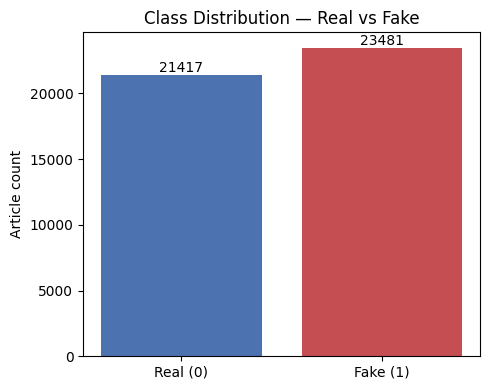

In [ ]:
import matplotlib.pyplot as plt

counts = df["label"].value_counts().sort_index()
labels = ["Real (0)", "Fake (1)"]

plt.figure(figsize=(5,4))
plt.bar(labels, counts.values, color=["#4C72B0", "#C44E52"])
plt.title("Class Distribution — Real vs Fake")
plt.ylabel("Article count")
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, str(v), ha="center")
plt.tight_layout()
plt.savefig("reports/class_distribution.png", dpi=150)
plt.show()

## 3. Shared EDA — word clouds (fake vs real)

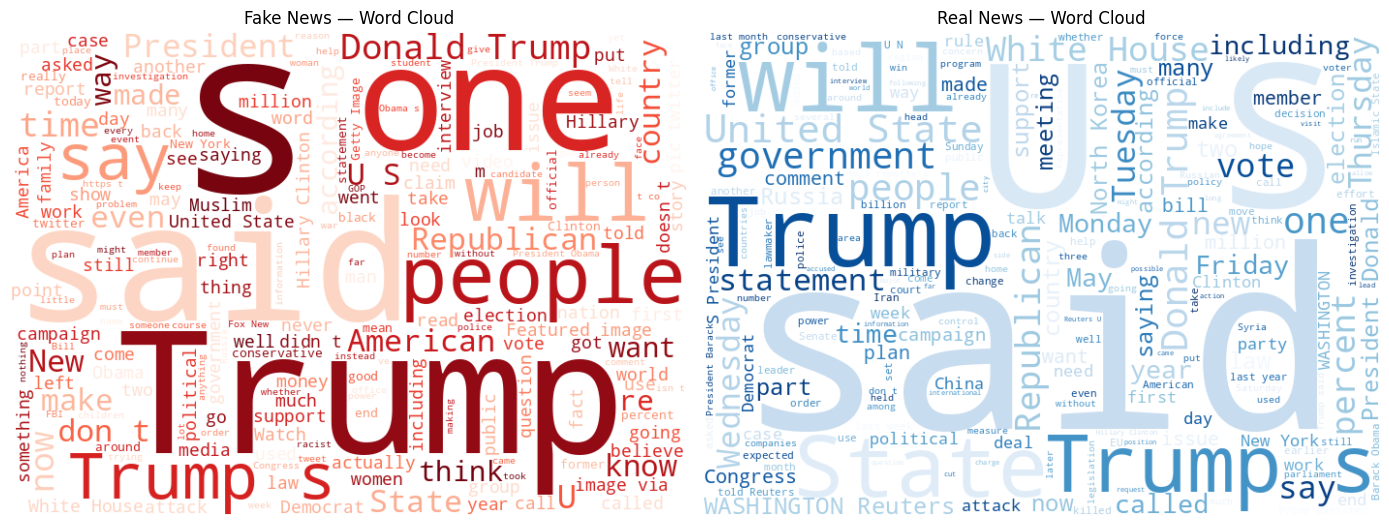

In [ ]:
from wordcloud import WordCloud

fake_text = " ".join(df[df.label == 1]["text"].astype(str).sample(3000, random_state=42))
real_text = " ".join(df[df.label == 0]["text"].astype(str).sample(3000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wc_fake = WordCloud(width=700, height=500, background_color="white", colormap="Reds").generate(fake_text)
axes[0].imshow(wc_fake, interpolation="bilinear")
axes[0].set_title("Fake News — Word Cloud")
axes[0].axis("off")

wc_real = WordCloud(width=700, height=500, background_color="white", colormap="Blues").generate(real_text)
axes[1].imshow(wc_real, interpolation="bilinear")
axes[1].set_title("Real News — Word Cloud")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("reports/wordclouds_fake_vs_real.png", dpi=150)
plt.show()

## 4. Shared EDA — article length histogram

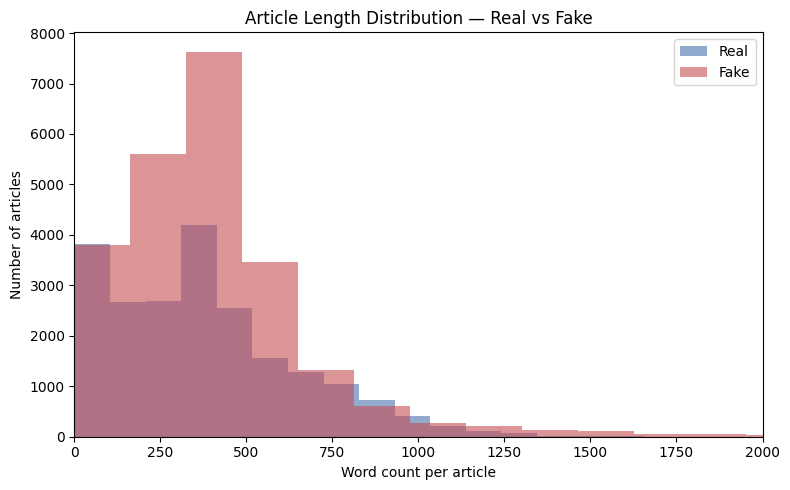

         count        mean         std  min    25%    50%    75%     max
label                                                                   
0      21417.0  385.640099  274.006204  0.0  148.0  359.0  525.0  5172.0
1      23481.0  423.197905  408.388890  0.0  240.0  363.0  506.0  8135.0


In [ ]:
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df[df.label == 0]["word_count"], bins=50, alpha=0.6, label="Real", color="#4C72B0")
plt.hist(df[df.label == 1]["word_count"], bins=50, alpha=0.6, label="Fake", color="#C44E52")
plt.xlim(0, 2000)
plt.xlabel("Word count per article")
plt.ylabel("Number of articles")
plt.title("Article Length Distribution — Real vs Fake")
plt.legend()
plt.tight_layout()
plt.savefig("reports/article_length_histogram.png", dpi=150)
plt.show()

print(df.groupby("label")["word_count"].describe())

## 5. Shared EDA — top-20 words per class

In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

def top_words(text_series, n=20):
    words = []
    for t in text_series.astype(str):
        tokens = re.findall(r"[a-z']+", t.lower())
        tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
        words.extend(tokens)
    return Counter(words).most_common(n)

top_fake = top_words(df[df.label == 1]["text"])
top_real = top_words(df[df.label == 0]["text"])

print("Top 20 words — FAKE:")
for w, c in top_fake:
    print(f"  {w:15s} {c}")

print("Top 20 words — REAL:")
for w, c in top_real:
    print(f"  {w:15s} {c}")

Top 20 words — FAKE:
  trump           79753
  said            33763
  president       27795
  people          26584
  one             24590
  would           23560
  clinton         19195
  obama           18800
  like            18116
  donald          17787
  also            15420
  news            14683
  new             14416
  hillary         14162
  even            14067
  time            13876
  state           13470
  white           13193
  via             12837
  twitter         11790
Top 20 words — REAL:
  said            99062
  trump           54647
  would           31605
  reuters         28974
  president       28176
  state           21021
  government      18843
  new             16915
  states          16653
  house           16640
  republican      16243
  also            15954
  united          15590
  people          15287
  year            14776
  told            14245
  could           13711
  one             13394
  washington      12988
  last            1275

---## 6. [M3] Preprocessing for SVMLowercase, remove punctuation & stopwords, lemmatize — per your task row.

In [ ]:
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

print(df["text"].iloc[0][:300])
print("--- cleaned ---")
print(preprocess_text(df["text"].iloc[0])[:300])

21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on Pres
--- cleaned ---
century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive order travel stein referred judgement circuit court washingto


**Note:** this runs on the full 44,898-row dataset next — it'll take a few minutes. That's expected for TF-IDF-scale preprocessing.

In [ ]:
from tqdm import tqdm
tqdm.pandas()

df["clean_text"] = df["text"].progress_apply(preprocess_text)
df[["text", "clean_text", "label"]].head()

100%|██████████| 44898/44898 [01:17<00:00, 582.06it/s]


,text,clean_text,label
0,"21st Century Wire says Ben Stein, reputable pr...",century wire say ben stein reputable professor...,1
1,WASHINGTON (Reuters) - U.S. President Donald T...,washington reuters president donald trump remo...,0
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...,reuters puerto rico governor ricardo rossello ...,0
3,"On Monday, Donald Trump once again embarrassed...",monday donald trump embarrassed country accide...,1
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",glasgow scotland reuters presidential candidat...,0


## 7. [M3] TF-IDF vectorizer for SVMPer your task: unigram + bigram, max 50,000 features. Fit on train only — actual train/test split with `random_state=42` happens in Week 4 once all 3 members sync up, so this cell just demonstrates the vectorizer working on the full cleaned text for now.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000
)

X_demo = tfidf.fit_transform(df["clean_text"])
print("TF-IDF matrix shape:", X_demo.shape)
print("Sample feature names:", tfidf.get_feature_names_out()[:20])

TF-IDF matrix shape: (44898, 50000)
Sample feature names: ['aadhaar' 'aapl' 'aaron' 'aaron bernstein' 'aarp' 'aba' 'ababa' 'aback'
 'abadi' 'abadi said' 'abandon' 'abandon nuclear' 'abandoned' 'abandoning'
 'abbas' 'abbasi' 'abbott' 'abbott said' 'abby' 'abc']


---## 8. [M3] DistilBERT tokenizer — verify shapes on a small batchPer your task: load `distilbert-base-uncased` tokenizer, tokenize a small batch, verify `input_ids` + `attention_mask` shapes. Max token length 512 (full-dataset tokenization happens in Week 4).

In [ ]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

sample_batch = df["text"].iloc[:8].tolist()

encoded = tokenizer(
    sample_batch,
    padding=True,
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

print("input_ids shape:     ", encoded["input_ids"].shape)
print("attention_mask shape:", encoded["attention_mask"].shape)
print("First article tokens (first 20):")
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])[:20])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

input_ids shape:      torch.Size([8, 512])
attention_mask shape: torch.Size([8, 512])
First article tokens (first 20):
['[CLS]', '21st', 'century', 'wire', 'says', 'ben', 'stein', ',', 'rep', '##utable', 'professor', 'from', ',', 'pepper', '##dine', 'university', '(', 'also', 'of', 'some']


## 9. Save your notebook's outputs and commitEDA charts already saved to `reports/`. Now save this notebook itself into `notebooks/` and commit — per the Week 3 goal: *"Each member commits their own preprocessing notebook to their branch."*

In [ ]:
!mkdir -p notebooks reports

In [ ]:
!git add reports/*.png

In [ ]:
!git status

On branch feature/CIT-24-0598-m3
Your branch is up to date with 'origin/feature/CIT-24-0598-m3'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   reports/article_length_histogram.png
	new file:   reports/class_distribution.png
	new file:   reports/wordclouds_fake_vs_real.png



---## ✅ Week 3 checklist (Member 3)- [ ] Shared EDA done: class distribution, word clouds, length histogram, top-20 words- [ ] Own preprocessing function written (lowercase, remove punctuation/stopwords, lemmatize)- [ ] TF-IDF vectorizer tested (unigram+bigram, max 50k features)- [ ] DistilBERT tokenizer loaded, input_ids/attention_mask shapes verified on a small batch- [ ] Notebook committed and pushed to your branch**Next — Week 4 (Feature Engineering):**- Sync with M1/M2 to confirm everyone uses `random_state=42` for the train/test split- Build the real TF-IDF vectorizer for SVM (fit on TRAIN only, save as `models/m3_tfidf_vectorizer.pkl`)- Tokenize the FULL dataset with the DistilBERT tokenizer, build a PyTorch Dataset with `input_ids`, `attention_mask`, `labels`Say the word when you're ready and I'll build that notebook.

In [29]:
 !ls notebooks/ —


ls: cannot access '—': No such file or directory
notebooks/:
'Copy of Week3_EDA_Preprocessing_M3.ipynb'


In [30]:
 import os;
 print(os.getcwd())

/content/drive/MyDrive/NLP_Group_10


In [31]:
!ls notebooks/

'Copy of Week3_EDA_Preprocessing_M3.ipynb'


In [32]:
!ls reports/

article_length_histogram.png  wordclouds_fake_vs_real.png
class_distribution.png


In [33]:
 !git add notebooks/*.ipynb reports/*.png

In [34]:
!git status

On branch feature/CIT-24-0598-m3
Your branch is up to date with 'origin/feature/CIT-24-0598-m3'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   notebooks/Copy of Week3_EDA_Preprocessing_M3.ipynb
	new file:   reports/article_length_histogram.png
	new file:   reports/class_distribution.png
	new file:   reports/wordclouds_fake_vs_real.png



In [39]:
!git commit -m "Added Week 3 EDA and SVM/DistilBERT preprocessing notebook"

[feature/CIT-24-0598-m3 cecdda1] Added Week 3 EDA and SVM/DistilBERT preprocessing notebook
 4 files changed, 1 insertion(+)
 create mode 100644 notebooks/Copy of Week3_EDA_Preprocessing_M3.ipynb
 create mode 100644 reports/article_length_histogram.png
 create mode 100644 reports/class_distribution.png
 create mode 100644 reports/wordclouds_fake_vs_real.png


In [36]:
!git commit -m "Added Week 3 EDA and SVM/DistilBERT preprocessing notebook"


Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@9d073981d582.(none)')


In [37]:
!git config --global user.name "Dulhari1"


In [38]:
!git config --global user.email "cit-24-01-0598@sltc.ac.lk"

In [40]:
!git push origin feature/CIT-24-0598-m3

Enumerating objects: 11, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 1.59 MiB | 2.14 MiB/s, done.
Total 8 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/cit-24-01-0486-sudo/NLP_Group_10.git
   fc5e85a..cecdda1  feature/CIT-24-0598-m3 -> feature/CIT-24-0598-m3
